# Resumen de performance por algoritmo (iteraciones)

Este notebook recorre todas las iteraciones en `Resultados/classification_exclude_prod`,
lee `resultados_modelos_completos.csv` y construye dos tablas:

- Accuracy (media y desviacion estandar)
- F1 Macro (media y desviacion estandar)

Columnas requeridas por tabla:

- Nitrogen, std Nitrogen, Phosphorus, std Phosphorus, Potassium, std Potassium

In [1]:
from pathlib import Path
import pandas as pd
from utils import plot_confusion_matrix

pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 160)

/home/student/PAI/venv-pai/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
I0000 00:00:1778773604.286797    8229 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1778773607.357168    8229 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1778773612.421779    8229 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [2]:
# Ruta base de iteraciones
base_path = Path('/home/student/PAI/Analisis-PAI/Resultados/classification_exclude_prod')

csv_files = sorted(base_path.glob('iter_*/resultados_modelos_completos.csv'))
print(f'CSV encontrados: {len(csv_files)}')
for p in csv_files[:5]:
    print('-', p)

if not csv_files:
    raise FileNotFoundError(f'No se encontraron archivos resultados_modelos_completos.csv en: {base_path}')

CSV encontrados: 20
- /home/student/PAI/Analisis-PAI/Resultados/classification_exclude_prod/iter_01_seed_42/resultados_modelos_completos.csv
- /home/student/PAI/Analisis-PAI/Resultados/classification_exclude_prod/iter_02_seed_43/resultados_modelos_completos.csv
- /home/student/PAI/Analisis-PAI/Resultados/classification_exclude_prod/iter_03_seed_44/resultados_modelos_completos.csv
- /home/student/PAI/Analisis-PAI/Resultados/classification_exclude_prod/iter_04_seed_45/resultados_modelos_completos.csv
- /home/student/PAI/Analisis-PAI/Resultados/classification_exclude_prod/iter_05_seed_46/resultados_modelos_completos.csv


In [3]:
# Cargar y concatenar todos los CSV de iteraciones
frames = []
for csv_path in csv_files:
    df_i = pd.read_csv(csv_path)
    df_i['iteration_folder'] = csv_path.parent.name
    frames.append(df_i)

df_all = pd.concat(frames, ignore_index=True)
print('Total filas consolidadas:', len(df_all))
df_all.head()

Total filas consolidadas: 300


,Model,N_Classes,Accuracy_Train,Accuracy_Test,F1_Train,F1_Test,F1_Macro_Test,Best_Params,iteration_folder
0,RF,3_Nitrogen,1.000000,0.764359,1.000000,0.764359,0.764013,"{'clf__max_depth': 20, 'clf__n_estimators': 200}",iter_01_seed_42
1,RF,3_Phosphorus,1.000000,0.771723,1.000000,0.771723,0.771754,"{'clf__max_depth': 30, 'clf__n_estimators': 200}",iter_01_seed_42
2,RF,3_Potassium,1.000000,0.780560,1.000000,0.780560,0.780056,"{'clf__max_depth': 30, 'clf__n_estimators': 300}",iter_01_seed_42
3,SVM,3_Nitrogen,1.000000,0.721649,1.000000,0.721649,0.721639,"{'clf__C': 100, 'clf__gamma': 0.1, 'clf__kerne...",iter_01_seed_42
4,SVM,3_Phosphorus,0.992261,0.736377,0.992261,0.736377,0.736264,"{'clf__C': 10, 'clf__gamma': 0.1, 'clf__kernel...",iter_01_seed_42


In [4]:
# Validar columnas requeridas
required_cols = ['Model', 'N_Classes', 'Accuracy_Test', 'F1_Macro_Test']
missing = [c for c in required_cols if c not in df_all.columns]
if missing:
    raise ValueError(f'Faltan columnas requeridas en los CSV: {missing}')

elements = ['Nitrogen', 'Phosphorus', 'Potassium']

# Extraer el elemento desde N_Classes (esperado: 3_Nitrogen, 3_Phosphorus, 3_Potassium)
df_all['Element'] = df_all['N_Classes'].astype(str).str.extract(r'3_(Nitrogen|Phosphorus|Potassium)', expand=False)
df_filtered = df_all[df_all['Element'].isin(elements)].copy()

if df_filtered.empty:
    raise ValueError('No se encontraron filas con N_Classes en formato 3_Nitrogen/3_Phosphorus/3_Potassium.')

# Forzar metricas a numerico
df_filtered['Accuracy_Test'] = pd.to_numeric(df_filtered['Accuracy_Test'], errors='coerce')
df_filtered['F1_Macro_Test'] = pd.to_numeric(df_filtered['F1_Macro_Test'], errors='coerce')

df_filtered = df_filtered.dropna(subset=['Accuracy_Test', 'F1_Macro_Test'])
print('Filas utiles para resumen:', len(df_filtered))
df_filtered[['Model', 'N_Classes', 'Element', 'Accuracy_Test', 'F1_Macro_Test']].head()

Filas utiles para resumen: 300


,Model,N_Classes,Element,Accuracy_Test,F1_Macro_Test
0,RF,3_Nitrogen,Nitrogen,0.764359,0.764013
1,RF,3_Phosphorus,Phosphorus,0.771723,0.771754
2,RF,3_Potassium,Potassium,0.780560,0.780056
3,SVM,3_Nitrogen,Nitrogen,0.721649,0.721639
4,SVM,3_Phosphorus,Phosphorus,0.736377,0.736264


In [5]:
# Agregar por algoritmo y elemento (media y std por metrica)
agg = (
    df_filtered
    .groupby(['Model', 'Element'], as_index=False)
    .agg(
        accuracy_mean=('Accuracy_Test', 'mean'),
        accuracy_std=('Accuracy_Test', 'std'),
        f1_macro_mean=('F1_Macro_Test', 'mean'),
        f1_macro_std=('F1_Macro_Test', 'std')
    )
)

agg.head()

,Model,Element,accuracy_mean,accuracy_std,f1_macro_mean,f1_macro_std
0,KNN,Nitrogen,0.729676,0.012149,0.729639,0.012267
1,KNN,Phosphorus,0.712518,0.017793,0.711417,0.017995
2,KNN,Potassium,0.737555,0.018682,0.736633,0.018837
3,MLP,Nitrogen,0.729602,0.014250,0.729502,0.014253
4,MLP,Phosphorus,0.732769,0.018839,0.732576,0.018826


In [6]:
def build_metric_table(agg_df, mean_col, std_col, elements_order):
    models = sorted(agg_df['Model'].unique())

    mean_wide = agg_df.pivot(index='Model', columns='Element', values=mean_col).reindex(columns=elements_order)
    std_wide = agg_df.pivot(index='Model', columns='Element', values=std_col).reindex(columns=elements_order)

    out = pd.DataFrame(index=models)
    for e in elements_order:
        out[e] = mean_wide[e]
        out[f'std {e}'] = std_wide[e]

    out.index.name = 'Model'
    return out.reset_index()

table_accuracy = build_metric_table(agg, 'accuracy_mean', 'accuracy_std', elements)
table_f1_macro = build_metric_table(agg, 'f1_macro_mean', 'f1_macro_std', elements)

# Redondear para visualizacion
table_accuracy = table_accuracy.round(4)
table_f1_macro = table_f1_macro.round(4)

In [7]:
print('Tabla final - Accuracy (media y std por elemento)')
display(table_accuracy.sort_values('Nitrogen', ascending=False))

print('Tabla final - F1 Macro (media y std por elemento)')
display(table_f1_macro.sort_values('Nitrogen', ascending=False))

# === Mejores iteraciones por elemento y métrica ===
best_rows = []
for elem in elements:
    df_e = df_filtered[df_filtered['Element'] == elem]
    if df_e.empty:
        continue
    # Mejor Accuracy
    idx_acc = df_e['Accuracy_Test'].idxmax()
    row_acc = df_e.loc[idx_acc]
    best_rows.append({
        'Element': elem,
        'Metric': 'Accuracy_Test',
        'Value': float(row_acc['Accuracy_Test']),
        'Model': row_acc['Model'],
        'Iteration': row_acc.get('iteration_folder', None)
    })
    # Mejor F1 Macro
    idx_f1 = df_e['F1_Macro_Test'].idxmax()
    row_f1 = df_e.loc[idx_f1]
    best_rows.append({
        'Element': elem,
        'Metric': 'F1_Macro_Test',
        'Value': float(row_f1['F1_Macro_Test']),
        'Model': row_f1['Model'],
        'Iteration': row_f1.get('iteration_folder', None)
    })


best_iterations_df = pd.DataFrame(best_rows)
print('\nMejores métricas por elemento (valor, modelo, iteración):')
display(best_iterations_df)

Tabla final - Accuracy (media y std por elemento)


,Model,Nitrogen,std Nitrogen,Phosphorus,std Phosphorus,Potassium,std Potassium
4,XGB,0.7876,0.0180,0.7957,0.0126,0.8135,0.0141
2,RF,0.7834,0.0146,0.7639,0.0168,0.7981,0.0162
3,SVM,0.7398,0.0165,0.7386,0.0190,0.7634,0.0194
0,KNN,0.7297,0.0121,0.7125,0.0178,0.7376,0.0187
1,MLP,0.7296,0.0143,0.7328,0.0188,0.7518,0.0141


Tabla final - F1 Macro (media y std por elemento)


,Model,Nitrogen,std Nitrogen,Phosphorus,std Phosphorus,Potassium,std Potassium
4,XGB,0.7875,0.0181,0.7956,0.0127,0.8135,0.0141
2,RF,0.7832,0.0146,0.7639,0.0168,0.7981,0.0163
3,SVM,0.7397,0.0165,0.7385,0.0191,0.7634,0.0194
0,KNN,0.7296,0.0123,0.7114,0.0180,0.7366,0.0188
1,MLP,0.7295,0.0143,0.7326,0.0188,0.7517,0.0141



Mejores métricas por elemento (valor, modelo, iteración):


,Element,Metric,Value,Model,Iteration
0,Nitrogen,Accuracy_Test,0.811487,XGB,iter_02_seed_43
1,Nitrogen,F1_Macro_Test,0.811504,XGB,iter_02_seed_43
2,Phosphorus,Accuracy_Test,0.820324,XGB,iter_11_seed_52
3,Phosphorus,F1_Macro_Test,0.820297,XGB,iter_11_seed_52
4,Potassium,Accuracy_Test,0.840943,XGB,iter_09_seed_50
5,Potassium,F1_Macro_Test,0.840977,XGB,iter_09_seed_50


3_Nitrogen
3_Nitrogen
3_Nitrogen


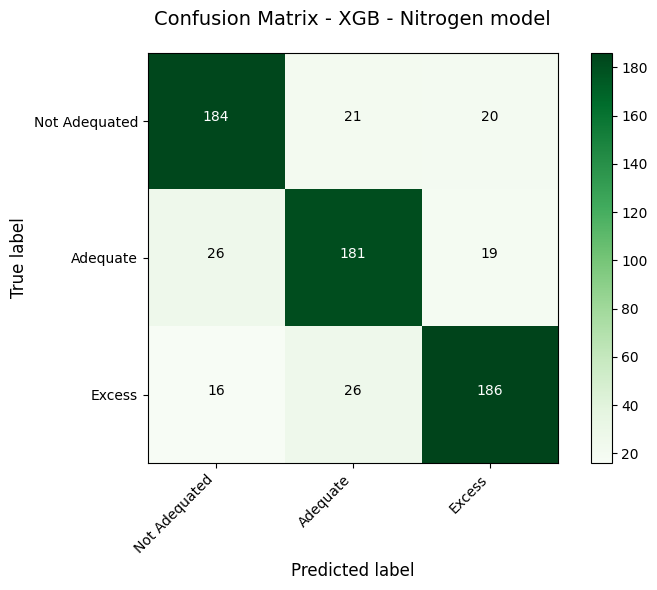

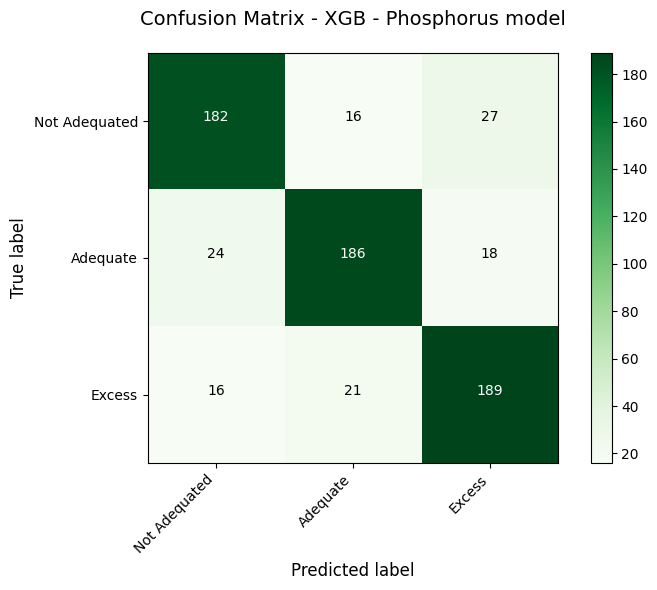

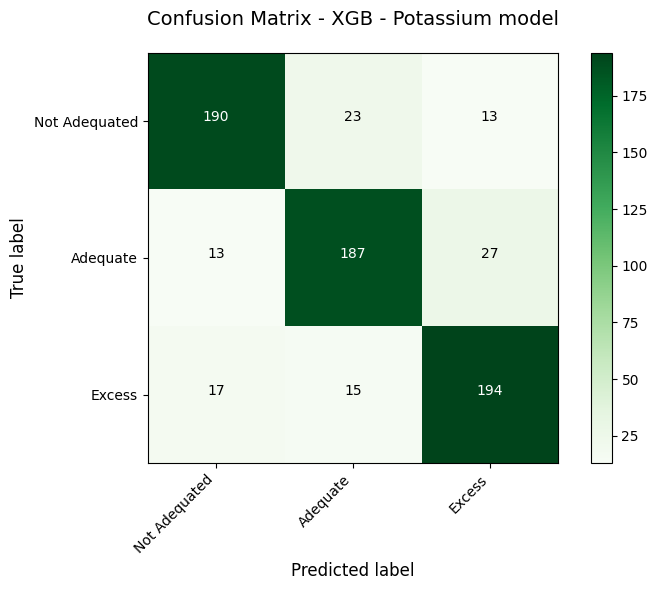

In [8]:
# Matrices de confusión para mejores iteraciones por elemento
for elem in elements:
    # extraer iteration y modelo para mejor Accuracy_Test
    best_acc_row = best_iterations_df[(best_iterations_df['Element'] == elem) & (best_iterations_df['Metric'] == 'Accuracy_Test')]
    if best_acc_row.empty:
        print(f'No se encontró mejor iteración para {elem} - Accuracy_Test')
        continue
    #crear ruta al modelo
    iteration_folder = best_acc_row['Iteration'].values[0]
    model_name = best_acc_row['Model'].values[0]
    model_path = base_path / iteration_folder / "class_results_individual_elements.pkl"
    if not model_path.exists():
        print(f'No se encontró el archivo de resultados individuales para {elem} - Accuracy_Test en: {model_path}')
        continue
    # cargar resultados individuales
    try:
        results_individual = pd.read_pickle(model_path)
    except Exception as e:
        print(f'Error al cargar el archivo de resultados individuales para {elem} - Accuracy_Test: {e}')
        continue
    value = results_individual[model_name]
    #print(value.keys())
    print((results_individual['RF'][0]['n_clases']))

    for resultado in value:
        if elem in resultado['n_clases']:
            fig = plot_confusion_matrix(resultado['confusion_matrix_test'], classes=['Not Adequated','Adequate','Excess'], 
                                title=f"Confusion Matrix - {model_name} - {resultado['n_clases'].split('_')[1] } model")
            # Create output directory if it doesn't exist
            output_dir = Path('confusion_matrices')
            output_dir.mkdir(exist_ok=True)
            fig.savefig(f"{output_dir}/{model_name}_{resultado['n_clases'].split('_')[1]}.pdf", bbox_inches='tight')

In [9]:
# Mejores métricas por modelo y elemento
best_model_rows = []
for model in df_filtered['Model'].unique():
    df_m = df_filtered[df_filtered['Model'] == model]
    for elem in elements:
        df_me = df_m[df_m['Element'] == elem]
        if df_me.empty:
            continue
        # Mejor Accuracy
        idx_acc = df_me['Accuracy_Test'].idxmax()
        row_acc = df_me.loc[idx_acc]
        best_model_rows.append({
            'Model': model,
            'Element': elem,
            'Metric': 'Accuracy_Test',
            'Value': float(row_acc['Accuracy_Test']),
            'Iteration': row_acc.get('iteration_folder', None)
        })
        # Mejor F1 Macro
        idx_f1 = df_me['F1_Macro_Test'].idxmax()
        row_f1 = df_me.loc[idx_f1]
        best_model_rows.append({
            'Model': model,
            'Element': elem,
            'Metric': 'F1_Macro_Test',
            'Value': float(row_f1['F1_Macro_Test']),
            'Iteration': row_f1.get('iteration_folder', None)
        })
best_model_iterations_df = pd.DataFrame(best_model_rows)
print('\nMejores métricas por modelo y elemento (valor, iteración):')
display(best_model_iterations_df)


Mejores métricas por modelo y elemento (valor, iteración):


,Model,Element,Metric,Value,Iteration
0,RF,Nitrogen,Accuracy_Test,0.805596,iter_02_seed_43
1,RF,Nitrogen,F1_Macro_Test,0.805580,iter_02_seed_43
2,RF,Phosphorus,Accuracy_Test,0.798233,iter_11_seed_52
3,RF,Phosphorus,F1_Macro_Test,0.798212,iter_11_seed_52
4,RF,Potassium,Accuracy_Test,0.827688,iter_14_seed_55
5,RF,Potassium,F1_Macro_Test,0.827634,iter_14_seed_55
6,SVM,Nitrogen,Accuracy_Test,0.770250,iter_02_seed_43
7,SVM,Nitrogen,F1_Macro_Test,0.770170,iter_02_seed_43
8,SVM,Phosphorus,Accuracy_Test,0.782032,iter_16_seed_57
9,SVM,Phosphorus,F1_Macro_Test,0.782094,iter_16_seed_57


In [10]:
# Guardar resultados en CSV (opcional)
output_dir = Path('/home/student/PAI/Analisis-PAI/train/train_iterations/iter_summary')
output_dir.mkdir(parents=True, exist_ok=True)

acc_path = output_dir / 'tabla_resumen_accuracy_iteraciones.csv'
f1_path = output_dir / 'tabla_resumen_f1_macro_iteraciones.csv'

table_accuracy.to_csv(acc_path, index=False)
table_f1_macro.to_csv(f1_path, index=False)

print('Archivos guardados:')
print('-', acc_path)
print('-', f1_path)

Archivos guardados:
- /home/student/PAI/Analisis-PAI/train/train_iterations/iter_summary/tabla_resumen_accuracy_iteraciones.csv
- /home/student/PAI/Analisis-PAI/train/train_iterations/iter_summary/tabla_resumen_f1_macro_iteraciones.csv


In [11]:
# Mejor iteracion en promedio (Accuracy) considerando todos los algoritmos
acc_by_iter = (
    df_filtered
    .groupby('iteration_folder', as_index=False)
    .agg(
        accuracy_mean_all_models=('Accuracy_Test', 'mean'),
        n_rows=('Accuracy_Test', 'size'),
        n_models=('Model', 'nunique')
    )
    .sort_values('accuracy_mean_all_models', ascending=False)
    .reset_index(drop=True)
)

acc_by_iter['accuracy_mean_all_models'] = acc_by_iter['accuracy_mean_all_models'].round(4)
best_iter_avg_accuracy = acc_by_iter.iloc[[0]].copy()

print('Ranking de iteraciones por Accuracy promedio (todos los algoritmos):')
display(acc_by_iter)

print('\nMejor iteracion promedio por Accuracy:')
display(best_iter_avg_accuracy)

Ranking de iteraciones por Accuracy promedio (todos los algoritmos):


,iteration_folder,accuracy_mean_all_models,n_rows,n_models
0,iter_04_seed_45,0.7692,15,5
1,iter_20_seed_61,0.7665,15,5
2,iter_19_seed_60,0.7665,15,5
3,iter_17_seed_58,0.7656,15,5
4,iter_07_seed_48,0.7649,15,5
5,iter_02_seed_43,0.7646,15,5
6,iter_13_seed_54,0.7641,15,5
7,iter_08_seed_49,0.7625,15,5
8,iter_16_seed_57,0.7612,15,5
9,iter_12_seed_53,0.7611,15,5



Mejor iteracion promedio por Accuracy:


,iteration_folder,accuracy_mean_all_models,n_rows,n_models
0,iter_04_seed_45,0.7692,15,5
